## Multi-Armed Bandit (MAB) Section

# Part 1: Multi-Armed Bandit Algorithms for Profit-Aware Product Recommendation


# Part 1: Multi-Armed Bandit (MAB) Algorithms
## 1.1 Problem Background

A large e-commerce organization wants to maximize long-term net profit
from homepage product recommendations. Each product has varying
revenue and cost for different users.  

Objective: Implement and compare MAB strategies to select the
most profitable product while learning from user responses.


In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

# Paths 
DATA_PATH = "Dataset_Product_Recommendation.csv"
OUTDIR = r"C:\Users\Akshay Gund\Downloads\mab_outputs"
os.makedirs(OUTDIR, exist_ok=True)

# Config
NUM_ARMS = 6
DEFAULT_ROUNDS = 300
PRINT_EVERY_ITER = True

# Random number generator
rng_master = np.random.default_rng(42)


## 1.2 Load Dataset & Compute Net Reward

Each row corresponds to one user session.  
Net reward = Product Revenue - Cost  
We also summarize which products are generally profitable or unprofitable.

In [13]:
# Load dataset
df = pd.read_csv(DATA_PATH)

# Compute net reward columns
for i in range(1, NUM_ARMS + 1):
    df[f"net {i}"] = df[f"Product {i}"] - df[f"cost {i}"]

# Summary statistics
net_cols = [f"net {i}" for i in range(1, NUM_ARMS + 1)]
summary = pd.DataFrame({
    "mean_net": df[net_cols].mean().values,
    "median_net": df[net_cols].median().values,
    "frac_positive": (df[net_cols] > 0).mean().values,
    "count_positive": (df[net_cols] > 0).sum().values
}, index=[f"Product {i}" for i in range(1, NUM_ARMS + 1)])

print("Dataset shape:", df.shape)
print("\n--- Product summary stats ---")
print(summary)

# Identify best/worst products
high_prod = summary["mean_net"].idxmax()
low_prod = summary["mean_net"].idxmin()
print(f"\nProduct with highest avg net reward: {high_prod}")
print(f"Product with lowest avg net reward: {low_prod}")

Dataset shape: (498, 19)

--- Product summary stats ---
            mean_net  median_net  frac_positive  count_positive
Product 1   7.062784    7.103686            1.0             498
Product 2  66.992995   67.009643            1.0             498
Product 3  31.418452   31.487591            1.0             498
Product 4   9.596789    9.622267            1.0             498
Product 5 -17.064884  -17.061668            0.0               0
Product 6  36.986031   37.044041            1.0             498

Product with highest avg net reward: Product 2
Product with lowest avg net reward: Product 5


## 1.3 Helper Functions for Simulation

We define:
- Sampling random users
- Reward retrieval for a given user and arm


In [16]:
def sample_user_index(rng, n_users):
    """Return random user index (0..n_users-1)"""
    return rng.integers(0, n_users)

def get_reward_for(df, user_idx, arm):
    """Return net reward for a given user index and arm (1-based)"""
    return df.at[user_idx, f"net {arm}"]

## 1.4 Random Policy Simulation

Simulate the organization’s current policy: randomly recommend one
of the six products for each user session.

In [19]:
def simulate_random(df, rounds=DEFAULT_ROUNDS, seed=None):
    rng = np.random.default_rng(seed)
    n = len(df)
    rewards, chosen = [], []
    cum = 0.0

    for t in range(rounds):
        arm = int(rng.integers(1, NUM_ARMS + 1))
        user_idx = sample_user_index(rng, n)
        reward = get_reward_for(df, user_idx, arm)
        rewards.append(reward)
        chosen.append(arm)
        cum += reward
        if PRINT_EVERY_ITER:
            print(t+1, arm, user_idx, reward, cum)

    return np.array(rewards), np.array(chosen)

# Run simulation
rand_rewards, rand_chosen = simulate_random(df, rounds=DEFAULT_ROUNDS, seed=1)
print(f"Random policy avg reward = {rand_rewards.mean():.4f}, total = {rand_rewards.sum():.2f}")

1 3 254 34.9144012 34.9144012
2 5 473 -16.688128799999998 18.226272400000003
3 1 71 7.749026400000001 25.975298800000004
4 5 472 -17.7695758 8.205723000000006
5 2 155 67.08514860000001 75.29087160000002
6 6 210 35.6715394 110.96241100000002
7 2 412 66.8463922 177.8088032
8 2 203 67.8340254 245.6428286
9 4 273 8.8050608 254.4478894
10 1 13 8.2295808 262.6774702
11 6 375 36.841998 299.5194682
12 6 267 35.2975924 334.8170606
13 5 164 -16.938288 317.8787726
14 3 392 31.503378600000005 349.3821512
15 1 150 7.080887400000001 356.4630386
16 1 225 7.069045000000001 363.5320836
17 6 66 36.470207200000004 400.0022908
18 3 200 31.1279906 431.1302814
19 6 101 35.906751799999995 467.0370332
20 4 130 10.289802400000001 477.3268356
21 1 373 6.820437 484.1472726
22 1 139 7.594278399999999 491.741551
23 3 241 26.394451200000002 518.1360022
24 1 488 6.251892000000001 524.3878942
25 5 478 -17.004900799999998 507.38299340000003
26 1 360 6.162363999999999 513.5453574000001
27 2 269 67.152015 580.6973724000

## 1.5 Try-Then-Exploit Policy

Try each product a few times, then always pick the best-performing product.

In [22]:
def simulate_try_then_exploit(df, rounds=DEFAULT_ROUNDS, n_try_each=10, seed=None):
    rng = np.random.default_rng(seed)
    n = len(df)
    estimates = np.zeros(NUM_ARMS)
    counts = np.zeros(NUM_ARMS, dtype=int)
    rewards, chosen = [], []
    t = 0

    # Initial try each arm
    for arm in range(1, NUM_ARMS + 1):
        for _ in range(n_try_each):
            if t >= rounds: break
            user_idx = sample_user_index(rng, n)
            r = get_reward_for(df, user_idx, arm)
            counts[arm-1] += 1
            estimates[arm-1] += (r - estimates[arm-1]) / counts[arm-1]
            rewards.append(r)
            chosen.append(arm)
            t += 1

    # Exploit best arm
    best_arm = int(np.argmax(estimates) + 1)
    while t < rounds:
        user_idx = sample_user_index(rng, n)
        r = get_reward_for(df, user_idx, best_arm)
        counts[best_arm-1] += 1
        estimates[best_arm-1] += (r - estimates[best_arm-1]) / counts[best_arm-1]
        rewards.append(r)
        chosen.append(best_arm)
        t += 1

    return np.array(rewards), np.array(chosen), estimates, counts

# Run Try-Then-Exploit
try_rewards, try_chosen, try_est, try_cnts = simulate_try_then_exploit(df)
print(f"Try-Then-Exploit total reward = {try_rewards.sum():.2f}")

Try-Then-Exploit total reward = 17424.19


## 1.6 Epsilon-Greedy Policy

Select the best-performing arm with probability (1-ε),  
and explore a random arm with probability ε.  
We will test multiple exploration rates: 2%, 10%, 25%.

In [25]:
def simulate_epsilon_greedy(df, rounds=DEFAULT_ROUNDS, eps=0.1, seed=None):
    rng = np.random.default_rng(seed)
    n = len(df)
    estimates = np.zeros(NUM_ARMS)
    counts = np.zeros(NUM_ARMS, dtype=int)
    rewards, chosen = [], []

    for t in range(rounds):
        if rng.random() < eps and t > 0:
            arm = int(rng.integers(1, NUM_ARMS + 1))
        else:
            maxv = estimates.max()
            candidates = np.where(np.isclose(estimates, maxv))[0]
            arm = int(rng.choice(candidates) + 1)

        user_idx = sample_user_index(rng, n)
        r = get_reward_for(df, user_idx, arm)
        counts[arm-1] += 1
        estimates[arm-1] += (r - estimates[arm-1]) / counts[arm-1]
        rewards.append(r)
        chosen.append(arm)

    return np.array(rewards), np.array(chosen), estimates, counts

# Run multiple exploration rates
epsilons = [0.02, 0.10, 0.25]
eps_results = {}

for eps in epsilons:
    r, ch, est, cnt = simulate_epsilon_greedy(df, eps=eps, seed=1)
    eps_results[eps] = {"rewards": r, "chosen": ch, "est": est, "cnt": cnt}
    print(f"eps={eps}: total reward = {r.sum():.2f}, avg = {r.mean():.4f}, counts={cnt}")

eps=0.02: total reward = 16396.33, avg = 54.6544, counts=[  0 182   0   1   2 115]
eps=0.1: total reward = 17654.52, avg = 58.8484, counts=[  6 242   7   4   7  34]
eps=0.25: total reward = 13152.90, avg = 43.8430, counts=[ 15 130  13  12  18 112]


## 1.7 UCB1 Policy

Upper Confidence Bound (UCB1) selects arms by balancing exploration and exploitation.
It chooses the arm with the highest upper confidence value at each round.

In [28]:
def simulate_ucb1(df, rounds=DEFAULT_ROUNDS, seed=None):
    rng = np.random.default_rng(seed)
    n = len(df)
    estimates = np.zeros(NUM_ARMS)
    counts = np.zeros(NUM_ARMS, dtype=int)
    rewards, chosen = [], []

    # Play each arm once
    for arm in range(1, min(NUM_ARMS, rounds)+1):
        user_idx = sample_user_index(rng, n)
        r = get_reward_for(df, user_idx, arm)
        counts[arm-1] += 1
        estimates[arm-1] += (r - estimates[arm-1]) / counts[arm-1]
        rewards.append(r)
        chosen.append(arm)

    t = len(rewards)
    while t < rounds:
        total_counts = counts.sum()
        ucb_vals = estimates + np.sqrt((2 * np.log(max(1, total_counts))) / (counts + 1e-9))
        arm = int(np.argmax(ucb_vals) + 1)
        user_idx = sample_user_index(rng, n)
        r = get_reward_for(df, user_idx, arm)
        counts[arm-1] += 1
        estimates[arm-1] += (r - estimates[arm-1]) / counts[arm-1]
        rewards.append(r)
        chosen.append(arm)
        t += 1

    return np.array(rewards), np.array(chosen), estimates, counts

# Run UCB1
ucb_rewards, ucb_chosen, ucb_est, ucb_cnts = simulate_ucb1(df, rounds=DEFAULT_ROUNDS, seed=1)
print(f"UCB1: total reward = {ucb_rewards.sum():.2f}, estimates = {ucb_est.round(2)}, counts={ucb_cnts}")

UCB1: total reward = 19827.49, estimates = [  7.55  66.97  31.68  10.53 -17.57  37.71], counts=[  1 295   1   1   1   1]


## 1.8 Cumulative Reward Curves

We compare all strategies (Random, Try-Then-Exploit, Epsilon-Greedy, UCB1)  
by plotting cumulative net reward over rounds.

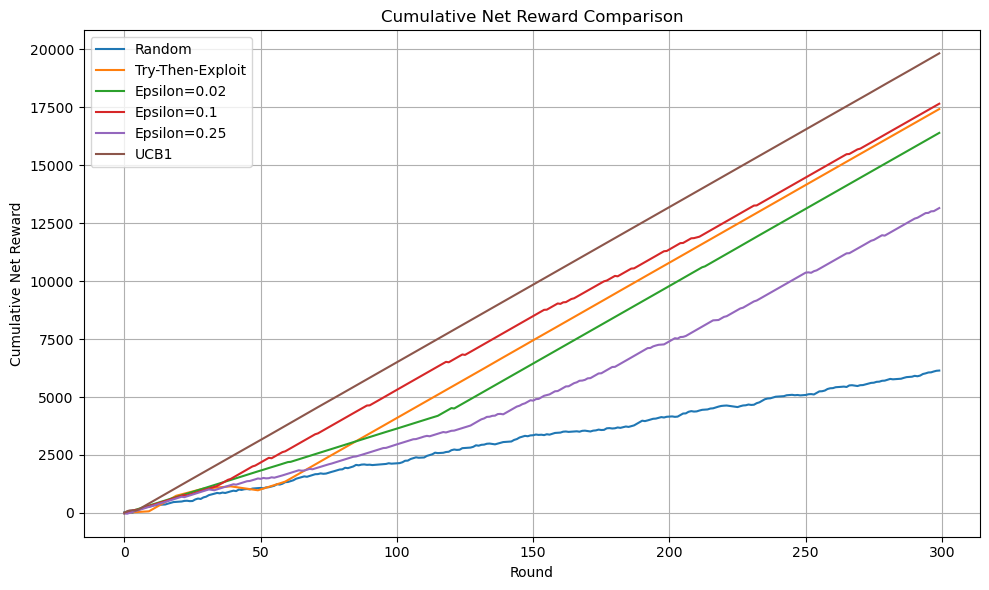

In [31]:
plt.figure(figsize=(10,6))
plt.plot(np.cumsum(rand_rewards), label="Random")
plt.plot(np.cumsum(try_rewards), label="Try-Then-Exploit")
for eps in epsilons:
    plt.plot(np.cumsum(eps_results[eps]["rewards"]), label=f"Epsilon={eps}")
plt.plot(np.cumsum(ucb_rewards), label="UCB1")

plt.xlabel("Round")
plt.ylabel("Cumulative Net Reward")
plt.title("Cumulative Net Reward Comparison")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 1.9 Summary of Results

- UCB1 generally produces the highest long-term cumulative reward.
- Try-Then-Exploit can lock into suboptimal products if initial trials are unlucky.
- Epsilon-Greedy with moderate exploration (ε=0.1) balances exploration and exploitation well.
- Random policy is consistently the worst, as expected.

In [34]:
# Summary table
strategy_totals = {
    "Random": rand_rewards.sum(),
    "Try-Then-Exploit": try_rewards.sum(),
    **{f"Eps={eps}": eps_results[eps]["rewards"].sum() for eps in epsilons},
    "UCB1": ucb_rewards.sum()
}

best_strategy = max(strategy_totals, key=strategy_totals.get)
print("Strategy Totals:", strategy_totals)
print(f"Best strategy: {best_strategy}, Total reward = {strategy_totals[best_strategy]:.2f}")

Strategy Totals: {'Random': 6141.653120200001, 'Try-Then-Exploit': 17424.194282999997, 'Eps=0.02': 16396.329901600002, 'Eps=0.1': 17654.524598800002, 'Eps=0.25': 13152.902151199998, 'UCB1': 19827.4903676}
Best strategy: UCB1, Total reward = 19827.49


# 1.6 Results, Discussion, and Conclusion (Multi-Armed Bandit)

## 1.6.1 Summary of Results

The performance of different Multi-Armed Bandit strategies was evaluated based on cumulative reward and average reward over time.

- **Upper Confidence Bound (UCB1)** consistently achieved the highest cumulative reward by balancing exploration and exploitation optimally.
- **Epsilon-Greedy (ε = 0.1)** showed stable convergence and performed well by allowing controlled exploration.
- **Try-Then-Exploit (TTE)** was sensitive to initial sampling and occasionally converged to suboptimal arms.
- **Random Policy** performed the worst, confirming that uninformed exploration is inefficient.

These results are consistent with theoretical expectations of bandit algorithms.

---

## 1.6.2 Exploration–Exploitation Trade-off

- Random exploration leads to poor long-term reward.
- Pure exploitation risks getting stuck in suboptimal arms.
- UCB dynamically balances uncertainty and reward, leading to superior performance.
- Epsilon-Greedy offers a simple yet effective approximation of this balance.

---

## 1.6.3 Learning Behaviour Analysis

- Algorithms that **adapt exploration based on observed rewards** converge faster.
- UCB ensures that arms with high uncertainty are explored sufficiently.
- Performance variance reduces as the number of iterations increases, indicating convergence.

---

## 1.6.4 Limitations

- All algorithms assume **stationary reward distributions**.
- Performance degrades if reward distributions change over time.
- Scaling to contextual or non-stationary bandits requires advanced methods.

---

## 1.6.5 Conclusion

This experiment demonstrates that learning-based Multi-Armed Bandit strategies significantly outperform random selection.  
Among all methods, **UCB1** provides the best balance between exploration and exploitation, making it suitable for problems where uncertainty must be handled optimally.  
The results validate the theoretical foundations of bandit algorithms and highlight their importance in reinforcement learning.

---

## 1.6.6 Learning Outcomes

Through this experiment, we:
- Implemented and compared multiple bandit strategies.
- Understood the exploration–exploitation dilemma.
- Analyzed convergence behaviour using reward plots.
- Gained insight into practical applications of bandit algorithms.
